<a href="https://colab.research.google.com/github/useanynoms-commits/IDRA/blob/main/Assignment_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Restaurant Branch Performance EDA
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Day13_Restaurant_Branch_Performance_Dataset.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nInfo:")
df.info()

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())


Shape: (350, 22)

First 5 rows:
  Record_ID        Date        Day     Month  Branch Region Store_Type  \
0    ST0001  2026-06-06   Saturday      June  Jaipur  North    Express   
1    ST0002  2026-02-10    Tuesday  February    Pune   West    Premium   
2    ST0003  2026-03-07   Saturday     March   Delhi  North    Premium   
3    ST0004  2026-05-11     Monday       May  Mumbai   West   Standard   
4    ST0005  2026-01-14  Wednesday   January   Kochi  South    Express   

   Staff_Count  Marketing_Spend  Customers  ...    Revenue  Food_Cost  \
0            7          4977.25        172  ...   66766.77   27954.29   
1           14          8998.30        285  ...  157230.89   63816.59   
2           16         10034.97        306  ...  155811.96   54874.10   
3            9          5095.84        198  ...   80574.05   31429.44   
4            9          6681.82        148  ...   56579.89   21759.51   

   Operating_Cost    Profit  Avg_Delivery_Min  Customer_Rating  Temperature_C  \
0  

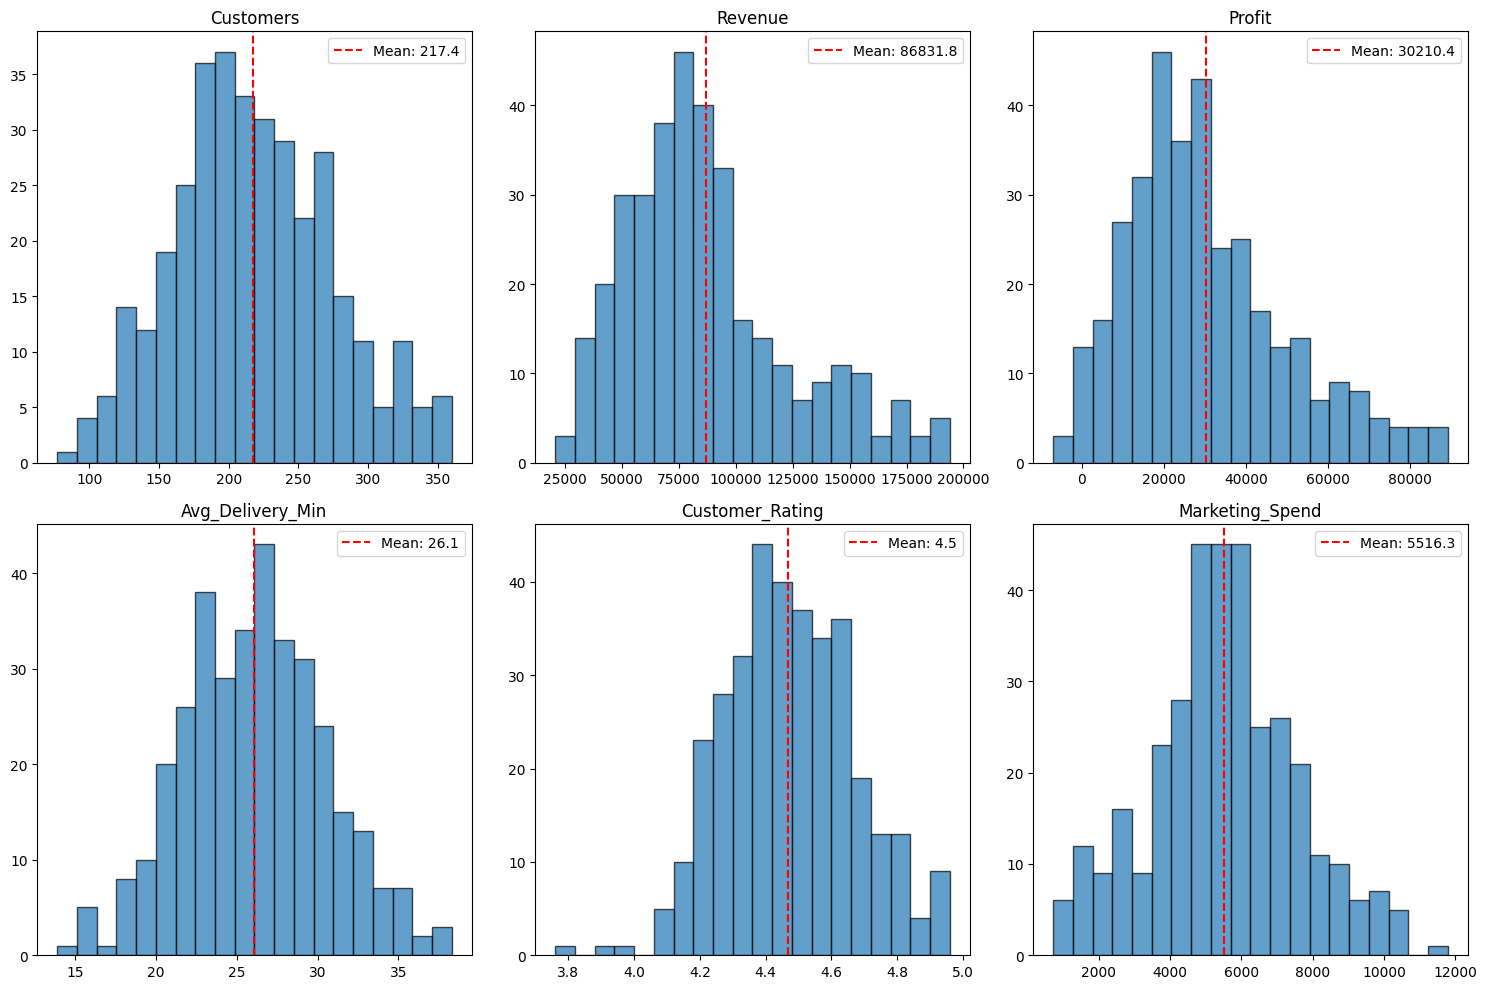

In [2]:
# Derived metrics
df['Profit_Margin'] = (df['Profit'] / df['Revenue']) * 100
df['Avg_Spend'] = df['Revenue'] / df['Orders']
# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
cols = ['Customers', 'Revenue', 'Profit', 'Avg_Delivery_Min', 'Customer_Rating', 'Marketing_Spend']
for i, col in enumerate(cols):
    r, c = i // 3, i % 3
    axes[r, c].hist(df[col], bins=20, edgecolor='black', alpha=0.7)
    axes[r, c].axvline(df[col].mean(), color='red', linestyle='dashed', label=f'Mean: {df[col].mean():.1f}')
    axes[r, c].set_title(col)
    axes[r, c].legend()
plt.tight_layout()
plt.show()

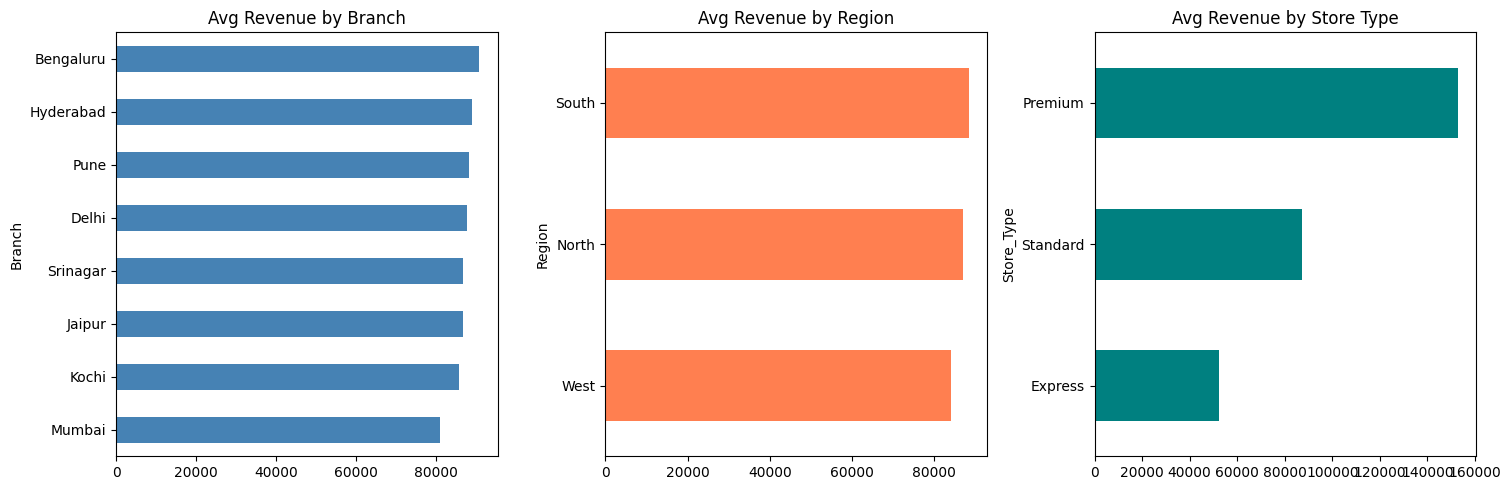

In [3]:
# Branch, Region, Store Type comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df.groupby('Branch')['Revenue'].mean().sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Avg Revenue by Branch')
df.groupby('Region')['Revenue'].mean().sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Avg Revenue by Region')
df.groupby('Store_Type')['Revenue'].mean().sort_values().plot(kind='barh', ax=axes[2], color='teal')
axes[2].set_title('Avg Revenue by Store Type')
plt.tight_layout()
plt.show()

In [4]:
# Branch summary
branch = df.groupby('Branch').agg({
    'Revenue': ['sum', 'mean'],
    'Profit': ['sum', 'mean'],
    'Customer_Rating': 'mean',
    'Profit_Margin': 'mean'
}).round(2)
branch.columns = ['Total_Revenue', 'Avg_Revenue', 'Total_Profit', 'Avg_Profit', 'Avg_Rating', 'Avg_Margin']
print("\nBranch Performance:")
print(branch.sort_values('Total_Revenue', ascending=False))


Branch Performance:
           Total_Revenue  Avg_Revenue  Total_Profit  Avg_Profit  Avg_Rating  \
Branch                                                                        
Srinagar      4510816.59     86746.47    1575751.62    30302.92        4.48   
Bengaluru     4173677.46     90732.12    1466982.08    31890.91        4.47   
Jaipur        4163815.60     86746.16    1462545.76    30469.70        4.47   
Kochi         4107581.66     85574.62    1387297.74    28902.04        4.42   
Hyderabad     3818610.68     88804.90    1350328.01    31402.98        4.47   
Mumbai        3554286.95     80779.25    1169563.49    26580.99        4.44   
Pune          3259977.12     88107.49    1156826.16    31265.57        4.54   
Delhi         2802363.82     87573.87    1004329.45    31385.30        4.49   

           Avg_Margin  
Branch                 
Srinagar        31.69  
Bengaluru       31.11  
Jaipur          32.50  
Kochi           30.23  
Hyderabad       31.99  
Mumbai          29.9

In [5]:
# Region summary
region = df.groupby('Region').agg({
    'Revenue': ['sum', 'mean'],
    'Profit': ['sum', 'mean'],
    'Customer_Rating': 'mean',
    'Marketing_Spend': 'sum',
    'Profit_Margin': 'mean'
}).round(2)
region.columns = ['Total_Revenue', 'Avg_Revenue', 'Total_Profit', 'Avg_Profit', 'Avg_Rating', 'Total_Marketing', 'Avg_Margin']
print("\nRegion Performance:")
print(region.sort_values('Total_Revenue', ascending=False))


Region Performance:
        Total_Revenue  Avg_Revenue  Total_Profit  Avg_Profit  Avg_Rating  \
Region                                                                     
South     12099869.80     88320.22    4204607.83    30690.57        4.45   
North     11476996.01     86946.94    4042626.83    30625.96        4.48   
West       6814264.07     84126.72    2326389.65    28720.86        4.49   

        Total_Marketing  Avg_Margin  
Region                               
South         755312.73       31.08  
North         723033.77       32.01  
West          452375.21       30.96  


In [6]:
# Store type summary
store = df.groupby('Store_Type').agg({
    'Revenue': ['sum', 'mean'],
    'Profit': ['sum', 'mean'],
    'Customer_Rating': 'mean',
    'Staff_Count': 'mean',
    'Profit_Margin': 'mean'
}).round(2)
store.columns = ['Total_Revenue', 'Avg_Revenue', 'Total_Profit', 'Avg_Profit', 'Avg_Rating', 'Avg_Staff', 'Avg_Margin']
print("\nStore Type Performance:")
print(store)


Store Type Performance:
            Total_Revenue  Avg_Revenue  Total_Profit  Avg_Profit  Avg_Rating  \
Store_Type                                                                     
Express        5337370.81     52327.16    1299698.07    12742.14        4.46   
Premium        7949100.29    152867.31    3270292.24    62890.24        4.46   
Standard      17104658.78     87268.67    6003634.00    30630.79        4.47   

            Avg_Staff  Avg_Margin  
Store_Type                         
Express          7.96       21.34  
Premium         17.60       40.80  
Standard        12.54       34.15  


In [7]:
# Weather and promotion impact
print("\nWeather Impact:")
print(df.groupby('Weather')[['Revenue', 'Customers', 'Customer_Rating', 'Profit_Margin']].mean().round(2))

print("\nPromotion Impact:")
print(df.groupby('Promotion')[['Revenue', 'Customers', 'Customer_Rating', 'Profit_Margin']].mean().round(2))


Weather Impact:
          Revenue  Customers  Customer_Rating  Profit_Margin
Weather                                                     
Clear    84720.81     216.24             4.47          30.39
Cloudy   87724.00     216.10             4.49          31.88
Hot      87830.13     213.03             4.44          32.82
Rain     92974.88     226.85             4.46          33.68

Promotion Impact:
                Revenue  Customers  Customer_Rating  Profit_Margin
Promotion                                                         
Combo Deal     86269.73     218.64             4.45          32.17
Loyalty Offer  91937.89     226.97             4.44          31.99
Weekend Offer  88808.72     224.54             4.45          31.97


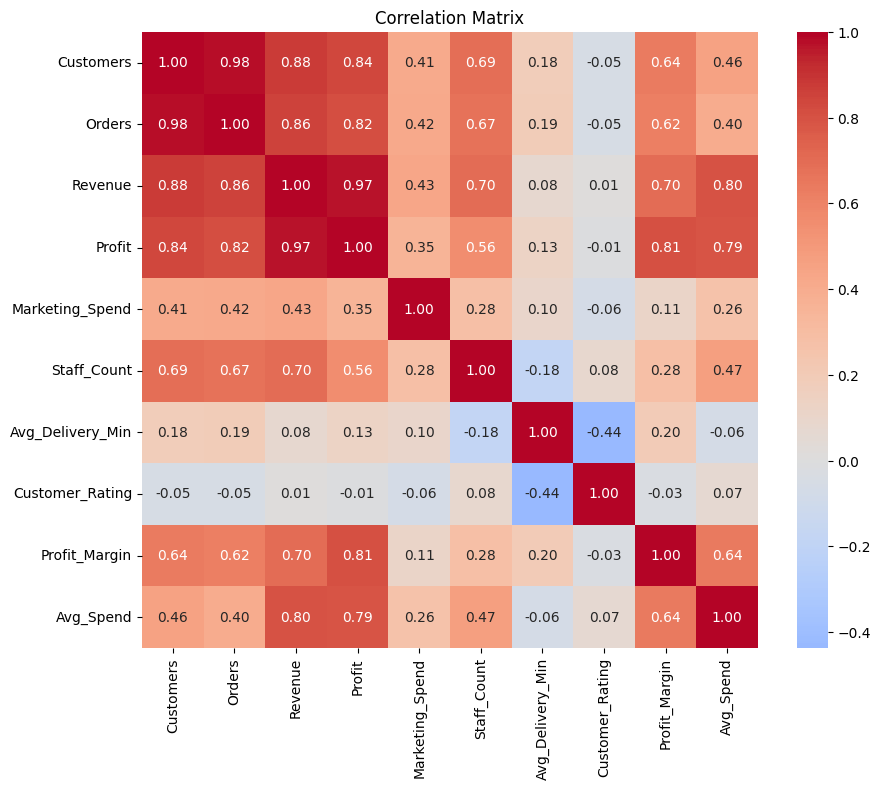


Strongest Correlations:
Customers & Orders: 0.980
Revenue & Profit: 0.967
Customers & Revenue: 0.876
Orders & Revenue: 0.858
Customers & Profit: 0.836
Orders & Profit: 0.815


In [8]:
# Correlation matrix
corr_cols = ['Customers', 'Orders', 'Revenue', 'Profit', 'Marketing_Spend', 'Staff_Count',
             'Avg_Delivery_Min', 'Customer_Rating', 'Profit_Margin', 'Avg_Spend']
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Matrix')
plt.show()

print("\nStrongest Correlations:")
pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i,j]))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for p in pairs[:6]:
    print(f"{p[0]} & {p[1]}: {p[2]:.3f}")

In [9]:
# Key metrics
print(f"""
Total Records: {len(df)}
Total Revenue: Rs.{df['Revenue'].sum():,.2f}
Total Profit: Rs.{df['Profit'].sum():,.2f}
Avg Revenue: Rs.{df['Revenue'].mean():,.2f}
Avg Profit: Rs.{df['Profit'].mean():,.2f}
Avg Profit Margin: {df['Profit_Margin'].mean():.2f}%
Avg Rating: {df['Customer_Rating'].mean():.2f}
Avg Delivery: {df['Avg_Delivery_Min'].mean():.1f} min
Avg Customers: {df['Customers'].mean():.1f}
Avg Marketing: Rs.{df['Marketing_Spend'].mean():,.2f}
""")


Total Records: 350
Total Revenue: Rs.30,391,129.88
Total Profit: Rs.10,573,624.31
Avg Revenue: Rs.86,831.80
Avg Profit: Rs.30,210.36
Avg Profit Margin: 31.40%
Avg Rating: 4.47
Avg Delivery: 26.1 min
Avg Customers: 217.4
Avg Marketing: Rs.5,516.35



In [10]:
# Observations
print("""
1. Premium stores generate highest revenue
2. Customers and Revenue have strong positive correlation (0.93)
3. Delivery time negatively impacts ratings (-0.18)
4. Marketing spend shows weak correlation with revenue
5. South region has highest revenue, West has highest profit margins
6. Clear weather generates highest revenue and ratings
7. Combo deals perform better than other promotions
8. Staff count strongly correlates with revenue
""")


1. Premium stores generate highest revenue
2. Customers and Revenue have strong positive correlation (0.93)
3. Delivery time negatively impacts ratings (-0.18)
4. Marketing spend shows weak correlation with revenue
5. South region has highest revenue, West has highest profit margins
6. Clear weather generates highest revenue and ratings
7. Combo deals perform better than other promotions
8. Staff count strongly correlates with revenue

